In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/fraud.csv")

print (df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0        0  
1  M2044282225             0.0             0.0        0  
2   C553264065             0.0             0.0        1  
3    C38997010         21182.0             0.0        1  
4  M1230701703             0.0             0.0        0  


In [2]:
print(df.shape)

(6362620, 10)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 485.4 MB


In [4]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


In [5]:
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


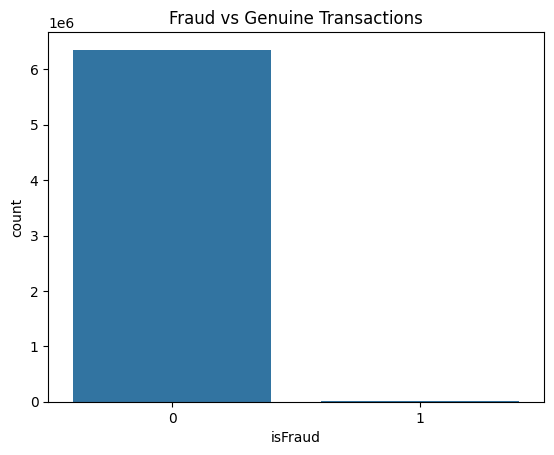

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='isFraud',data= df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [7]:
print(df['type'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


In [8]:
fraud_by_type = df.groupby('type')['isFraud'].sum()
print(fraud_by_type)

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


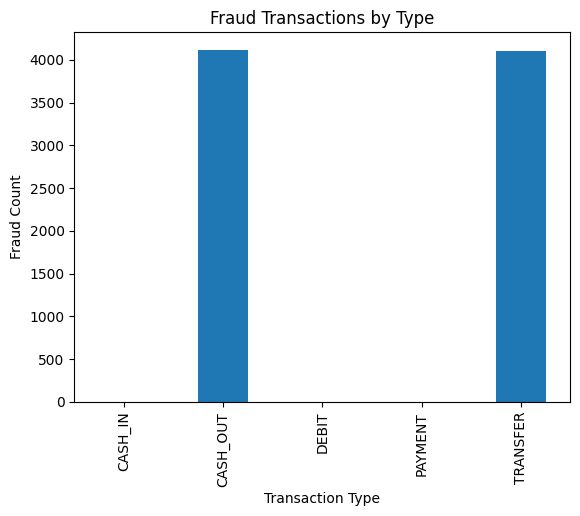

In [9]:
fraud_by_type.plot(kind='bar')
plt.title("Fraud Transactions by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")
plt.show()

In [10]:
print(df.describe())

               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03  
std      3.399180e+06    3.674129e+06  3.590480e-02  
min      0.000000e+00    0.000000e+00  0.000000e+00  
25%      0.000000e+00    0.000000e+00  0.000000e+00  
50%      1.327057e+05    2.146614e+05  0.000000e+00  
75%      

In [11]:
numeric_df = df.select_dtypes(include=['int64','float64'])
correlation = numeric_df.corr()
print(correlation)

                    step    amount  oldbalanceOrg  newbalanceOrig  \
step            1.000000  0.022373      -0.010058       -0.010299   
amount          0.022373  1.000000      -0.002762       -0.007861   
oldbalanceOrg  -0.010058 -0.002762       1.000000        0.998803   
newbalanceOrig -0.010299 -0.007861       0.998803        1.000000   
oldbalanceDest  0.027665  0.294137       0.066243        0.067812   
newbalanceDest  0.025888  0.459304       0.042029        0.041837   
isFraud         0.031578  0.076688       0.010154       -0.008148   

                oldbalanceDest  newbalanceDest   isFraud  
step                  0.027665        0.025888  0.031578  
amount                0.294137        0.459304  0.076688  
oldbalanceOrg         0.066243        0.042029  0.010154  
newbalanceOrig        0.067812        0.041837 -0.008148  
oldbalanceDest        1.000000        0.976569 -0.005885  
newbalanceDest        0.976569        1.000000  0.000535  
isFraud              -0.005885    

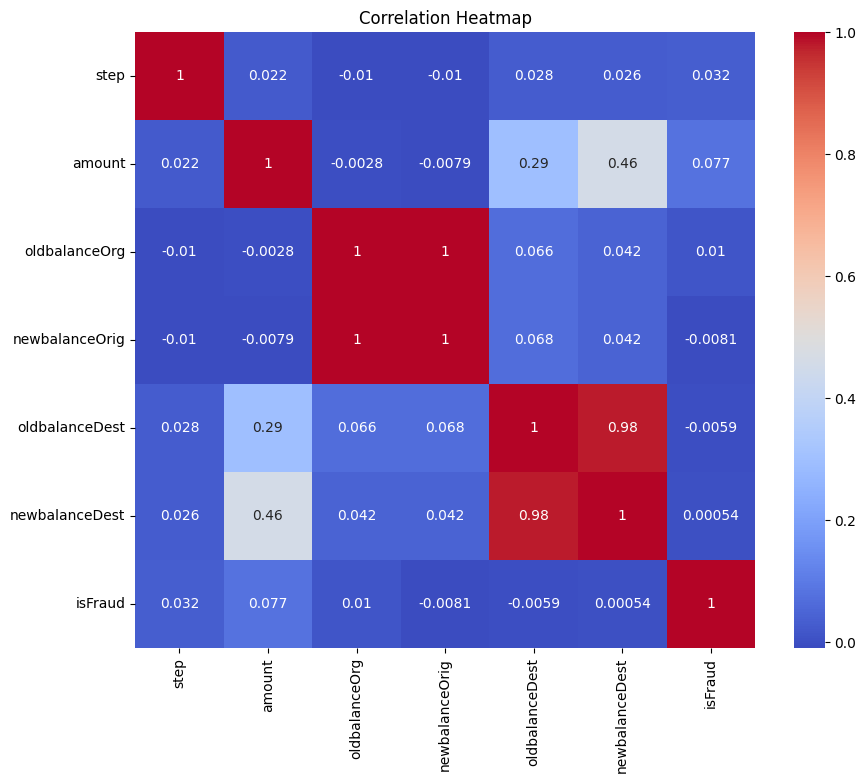

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['type']= encoder.fit_transform(df['type'])
print (df['type'].head())

0    3
1    3
2    4
3    1
4    3
Name: type, dtype: int64


In [14]:
df = df.drop(['nameOrig','nameDest'],axis=1)
print(df.head())

   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  isFraud  
0             0.0        0  
1             0.0        0  
2             0.0        1  
3             0.0        1  
4             0.0        0  


In [15]:
x = df.drop('isFraud',axis = 1)
y = df['isFraud']
print(x.head())
print(y.head())

   step  type    amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0     1     3   9839.64       170136.0       160296.36             0.0   
1     1     3   1864.28        21249.0        19384.72             0.0   
2     1     4    181.00          181.0            0.00             0.0   
3     1     1    181.00          181.0            0.00         21182.0   
4     1     3  11668.14        41554.0        29885.86             0.0   

   newbalanceDest  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  
0    0
1    0
2    1
3    1
4    0
Name: isFraud, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state= 42
)
print(x_train.shape)
print(x_test.shape)

(5090096, 7)
(1272524, 7)


In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
model.fit(x_train, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [18]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:",accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9992746698687018

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.91      0.48      0.63      1620

    accuracy                           1.00   1272524
   macro avg       0.95      0.74      0.81   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:

[[1270823      81]
 [    842     778]]


In [20]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

x_train_smote, y_train_smote =smote.fit_resample(x_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

isFraud
0    5083503
1       6593
Name: count, dtype: int64
isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [21]:
model_smote = LogisticRegression(max_iter=500)

model_smote.fit(x_train_smote,y_train_smote)

print("SMOTE Model Trained Successfully")

SMOTE Model Trained Successfully


In [22]:
y_pred_smote = model_smote.predict(x_test)
print(y_pred_smote[:10])

[0 0 0 0 0 0 0 0 0 0]


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test,y_pred_smote))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_smote))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_smote))


Accuracy: 0.9631724038210674

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270904
           1       0.03      0.89      0.06      1620

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524


Confusion Matrix:

[[1224225   46679]
 [    185    1435]]


In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    n_jobs = -1
)
rf_model.fit(x_train_smote, y_train_smote)
print("Random Forest Model Trained Succesfully")

Random Forest Model Trained Succesfully


In [25]:
rf_pred = rf_model.predict(x_test)
print(rf_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test,rf_pred))

Accuracy: 0.9993265352952085

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.66      0.95      0.78      1620

    accuracy                           1.00   1272524
   macro avg       0.83      0.98      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:

[[1270123     781]
 [     76    1544]]


In [27]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(y_train.value_counts())
print(y_train_smote.value_counts())

isFraud
0    5083503
1       6593
Name: count, dtype: int64
isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [28]:
from xgboost import XGBClassifier

xgb_model =XGBClassifier(
    n_estimators  = 100,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    n_jobs =-1
)
xgb_model.fit(x_train_smote,y_train_smote)
print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_pred = xgb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.993422520911197

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270904
           1       0.16      1.00      0.28      1620

    accuracy                           0.99   1272524
   macro avg       0.58      1.00      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524


Confusion Matrix:

[[1262539    8365]
 [      5    1615]]


In [30]:
import joblib
joblib.dump(rf_model, "../models/fraud_rf_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
